# Task 2 Best Model Deep Analysis

This notebook analyzes only the selected best deployable Task 2 pipeline:

**Task1-best parent candidates + Task2 cross-encoder reranker, alpha = 15.**

The previous best and oracle/known-parent upper bounds are included only as context for comparison.

In [11]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report

def find_package_task_dir(expected_file):
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "task2", cwd.parent, cwd.parent.parent, cwd / "final_best_models_package" / "task2"]
    for candidate in candidates:
        if (candidate / "models" / expected_file).exists():
            return candidate
    raise FileNotFoundError(f"Could not find packaged models/{expected_file}. Current working directory: {cwd}")

BASE = find_package_task_dir("best_alpha15_metrics.json")
MODEL_DIR = BASE / "models"
OUT = BASE / "analysis_outputs"
OUT.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)
print("Using model directory:", MODEL_DIR)

Using model directory: C:\Users\shami\OneDrive\Desktop\capstone\final_best_models_package\task2\models


In [12]:
metrics = json.load(open(MODEL_DIR / "best_alpha15_metrics.json", encoding="utf-8"))
parent_metrics = json.load(open(MODEL_DIR / "task1_parent_candidate_metrics.json", encoding="utf-8"))
comparison = pd.read_csv(MODEL_DIR / "task2_best_model_comparison_alpha15.csv")

print("Best deployable Task 2 metrics")
display(pd.Series(metrics["test"]).to_frame("score"))
print("Task 1 parent candidate recall used by Task 2")
display(pd.Series(parent_metrics["test"]).to_frame("recall"))
display(comparison)

Best deployable Task 2 metrics


,score
accuracy,0.748940
macro_f1,0.576095
weighted_f1,0.731026
top10_macro_f1,0.890520
top1_accuracy,0.748940
top3_accuracy,0.901382
top5_accuracy,0.924055
mrr,0.828908


Task 1 parent candidate recall used by Task 2


,recall
parent_top1_recall,0.907650
parent_top3_recall,0.972535
parent_top5_recall,0.986175
parent_top10_recall,0.993733


,model,accuracy,macro_f1,weighted_f1,top10_macro_f1,top1,top3,top5,mrr
0,NEW task1-best candidates + CE reranker (alpha=15),0.748940,0.576095,0.731026,0.890520,0.748940,0.901382,0.924055,0.828908
1,OLD best deployable task1_mt_rerank,0.622417,0.506979,0.611627,0.699498,NaN,NaN,NaN,NaN
2,Known-parent local upper bound,0.820812,0.653432,0.807933,0.864103,NaN,NaN,NaN,NaN
3,v2 label/GECS reranker,0.579215,0.472752,0.571738,0.662882,NaN,NaN,NaN,NaN
4,v3 OOF stacking reranker,0.575097,0.462094,0.559225,0.654450,NaN,NaN,NaN,NaN
5,Oracle-parent CE ranking upper bound,0.857512,NaN,NaN,NaN,0.857512,0.988756,0.998341,0.921383


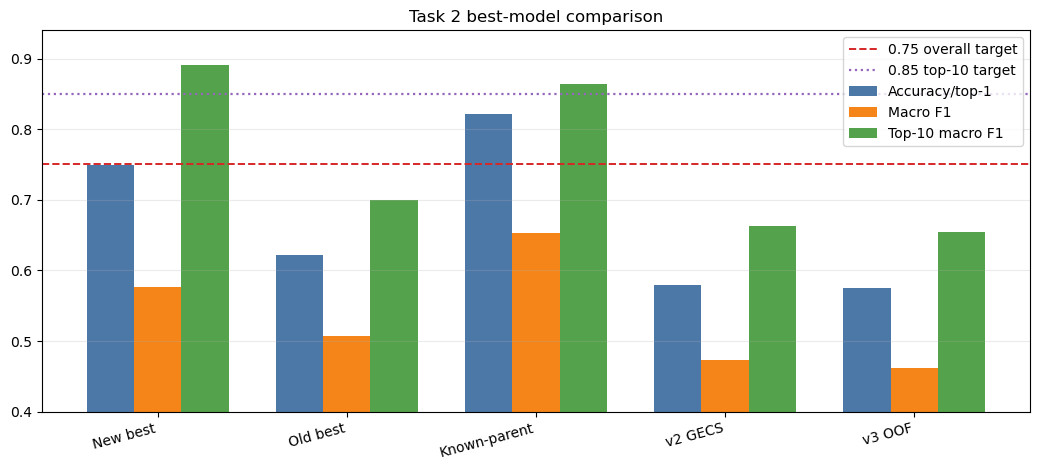

In [13]:
fig, ax = plt.subplots(figsize=(10.5, 4.8))
plot_df = comparison[comparison["model"].isin([
    "v2 label/GECS reranker",
    "v3 OOF stacking reranker",
    "OLD best deployable task1_mt_rerank",
    "NEW task1-best candidates + CE reranker (alpha=15)",
    "Known-parent local upper bound",
])].copy()
plot_df["model"] = plot_df["model"].replace({
    "OLD best deployable task1_mt_rerank": "Old best",
    "NEW task1-best candidates + CE reranker (alpha=15)": "New best",
    "Known-parent local upper bound": "Known-parent",
    "v2 label/GECS reranker": "v2 GECS",
    "v3 OOF stacking reranker": "v3 OOF",
})
x = np.arange(len(plot_df))
w = 0.25
ax.bar(x - w, plot_df["accuracy"], width=w, label="Accuracy/top-1", color="#4c78a8")
ax.bar(x, plot_df["macro_f1"], width=w, label="Macro F1", color="#f58518")
ax.bar(x + w, plot_df["top10_macro_f1"], width=w, label="Top-10 macro F1", color="#54a24b")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=15, ha="right")
ax.set_ylim(0.40, 0.94)
ax.axhline(0.75, color="#d62728", linestyle="--", linewidth=1.4, label="0.75 overall target")
ax.axhline(0.85, color="#9467bd", linestyle=":", linewidth=1.6, label="0.85 top-10 target")
ax.grid(axis="y", alpha=0.25)
ax.legend()
ax.set_title("Task 2 best-model comparison")
fig.tight_layout()
fig.savefig(OUT / "task2_best_model_comparison.png", dpi=180)
plt.show()

,alpha,val_accuracy,val_macro_f1,val_weighted_f1,val_top10_macro_f1,val_top1_accuracy,val_top3_accuracy,val_top5_accuracy,val_mrr
0,15,0.749308,0.588512,0.732224,0.913656,0.749308,0.896145,0.921417,0.827251
1,20,0.749493,0.587503,0.732705,0.910622,0.749493,0.893747,0.918650,0.826650
2,12,0.747279,0.587057,0.729528,0.914428,0.747279,0.898727,0.924737,0.827049
3,50,0.748939,0.586409,0.733041,0.907110,0.748939,0.886921,0.911087,0.823347
4,10,0.747279,0.586323,0.728848,0.919510,0.747279,0.900572,0.926213,0.827464
5,30,0.747833,0.586293,0.731619,0.906648,0.747833,0.889504,0.914591,0.824278
6,80,0.748386,0.585386,0.732549,0.906223,0.748386,0.885261,0.909057,0.822234
7,8,0.741192,0.580796,0.721693,0.923064,0.741192,0.900203,0.928795,0.824644


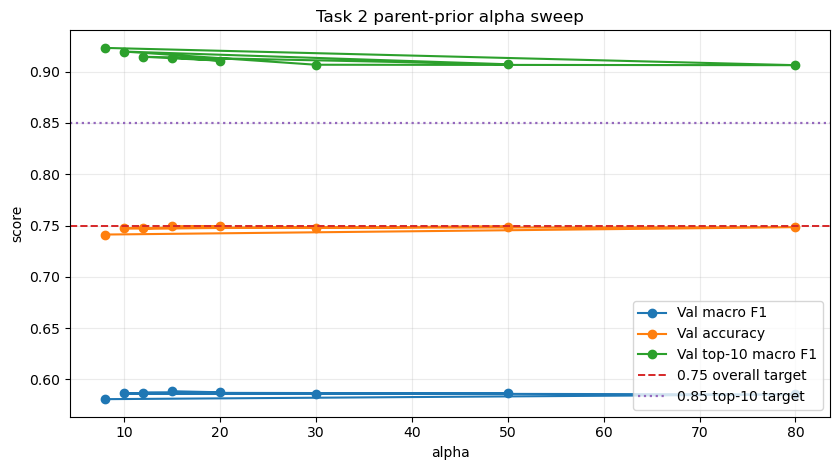

In [14]:
alpha_files = [
    MODEL_DIR / "alpha_sweep_extended2.csv",
    MODEL_DIR / "alpha_sweep_extended.csv",
    MODEL_DIR / "alpha_sweep.csv",
]
alpha_path = next((p for p in alpha_files if p.exists()), None)
alpha = pd.read_csv(alpha_path)
display(alpha.sort_values("val_macro_f1", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(alpha["alpha"], alpha["val_macro_f1"], marker="o", label="Val macro F1")
if "val_accuracy" in alpha:
    ax.plot(alpha["alpha"], alpha["val_accuracy"], marker="o", label="Val accuracy")
if "val_top10_macro_f1" in alpha:
    ax.plot(alpha["alpha"], alpha["val_top10_macro_f1"], marker="o", label="Val top-10 macro F1")
ax.set_xlabel("alpha")
ax.set_ylabel("score")
ax.axhline(0.75, color="#d62728", linestyle="--", linewidth=1.4, label="0.75 overall target")
ax.axhline(0.85, color="#9467bd", linestyle=":", linewidth=1.6, label="0.85 top-10 target")
ax.set_title("Task 2 parent-prior alpha sweep")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "task2_alpha_sweep.png", dpi=180)
plt.show()

In [15]:
pred = pd.read_csv(MODEL_DIR / "best_predictions_test_alpha15.csv", dtype=str)
y_true = pred["true_leaf"].astype(str).to_numpy()
y_pred = pred["candidate_leaf"].astype(str).to_numpy()

taxonomy = pd.read_csv(MODEL_DIR / "taxonomy_table.csv", dtype=str)
leaf_name = taxonomy.drop_duplicates("subindustry_code").set_index("subindustry_code")["subindustry_name"].to_dict()
parent_name = taxonomy.drop_duplicates("industry_code").set_index("industry_code")["industry_name"].to_dict()

report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
rows = []
for code, vals in report.items():
    if code in {"accuracy", "macro avg", "weighted avg"}:
        continue
    rows.append({
        "subindustry_code": code,
        "subindustry_name": leaf_name.get(code, ""),
        "parent_code": code[:8],
        "parent_name": parent_name.get(code[:8], ""),
        "precision": vals["precision"],
        "recall": vals["recall"],
        "f1": vals["f1-score"],
        "support": vals["support"],
    })
per_class = pd.DataFrame(rows).sort_values(["f1", "support"], ascending=[True, False])
per_class.to_csv(OUT / "task2_alpha15_per_class_metrics.csv", index=False)
display(per_class[per_class["support"] >= 10].head(25))

,subindustry_code,subindustry_name,parent_code,parent_name,precision,recall,f1,support
353,3108006002,,31080060,Integrated Freight & Logistics,0.000000,0.000000,0.000000,52.0
148,1041001002,,10410010,Real Estate - Development,0.000000,0.000000,0.000000,47.0
235,2072002006,,20720020,Utilities - Regulated Electric,0.000000,0.000000,0.000000,40.0
239,2072003003,,20720030,Utilities - Regulated Gas,0.000000,0.000000,0.000000,18.0
114,1031001001,Diversified Fund,10310010,Asset Management,0.000000,0.000000,0.000000,15.0
11,1013001002,Organic Basic Chemicals Manufacturer,10130010,Chemicals,0.000000,0.000000,0.000000,11.0
119,1031001099,Other Asset Management Services,10310010,Asset Management,0.400000,0.125000,0.190476,16.0
200,2064501002,Healthcare Facility Ancillary Services,20645010,Medical Care Facilities,0.666667,0.200000,0.307692,10.0
297,3104001001,Engineering Services,31040010,Engineering & Construction,0.421053,0.275862,0.333333,29.0
298,3104001002,Construction of Non Residential Buildings - Development,31040010,Engineering & Construction,0.500000,0.250000,0.333333,28.0


,subindustry_code,subindustry_name,parent_code,parent_name,precision,recall,f1,support
296,3103001001,Conglomerates,31030010,Conglomerates,0.854369,0.877805,0.865929,401.0
149,1041002001,Acquisition and Ownership of Buildings,10410020,Real Estate Services,0.838235,0.844444,0.841328,135.0
124,1032002001,Regional Retail Banking,10320020,Banks - Regional,0.851852,0.927419,0.888031,124.0
115,1031001002,Investment Management,10310010,Asset Management,0.722628,0.838983,0.776471,118.0
182,2052504001,Packaged or Frozen Food Manufacturer,20525040,Packaged Foods,0.930000,0.939394,0.934673,99.0
13,1013001099,Other Chemical Products Manufacturer,10130010,Chemicals,0.685714,0.521739,0.592593,92.0
302,3104001099,Other Engineering Projects,31040010,Engineering & Construction,0.617391,0.806818,0.699507,88.0
324,3107002098,Other Renewable Energy Technologies,31070020,Specialty Industrial Machinery,0.611111,0.776471,0.683938,85.0
145,1036001001,Credit Provider,10360010,Credit Services,0.886076,0.875000,0.880503,80.0
197,2062002001,Drug Manufacturers - Specialty & Generic,20620020,Drug Manufacturers - Specialty & Generic,0.914286,0.914286,0.914286,70.0


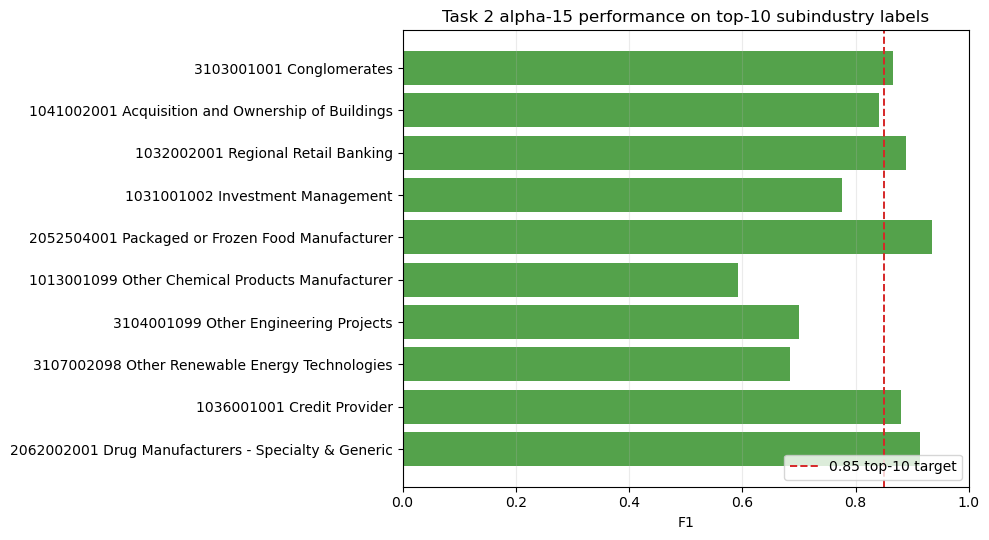

In [16]:
top10 = pd.Series(y_true).value_counts().head(10).index.astype(str).tolist()
top10_df = per_class[per_class["subindustry_code"].isin(top10)].sort_values("support", ascending=False)
display(top10_df)

fig, ax = plt.subplots(figsize=(10, 5.5))
labels = top10_df["subindustry_code"] + " " + top10_df["subindustry_name"].fillna("")
ax.barh(labels[::-1], top10_df["f1"][::-1], color="#54a24b")
ax.set_xlim(0, 1)
ax.axvline(0.85, color="#d62728", linestyle="--", linewidth=1.4, label="0.85 top-10 target")
ax.set_title("Task 2 alpha-15 performance on top-10 subindustry labels")
ax.set_xlabel("F1")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUT / "task2_top10_subindustry_f1.png", dpi=180)
plt.show()

In [17]:
conf = pd.DataFrame({"true": y_true, "pred": y_pred})
conf = conf[conf["true"] != conf["pred"]]
pairs = (
    conf.groupby(["true", "pred"]).size().reset_index(name="count")
    .sort_values("count", ascending=False)
)
pairs["true_name"] = pairs["true"].map(leaf_name).fillna("")
pairs["pred_name"] = pairs["pred"].map(leaf_name).fillna("")
pairs["same_parent"] = pairs["true"].str[:8] == pairs["pred"].str[:8]
pairs.to_csv(OUT / "task2_top_confusion_pairs.csv", index=False)
display(pairs.head(30))
print("Share of mistakes within the same parent:", pairs.loc[pairs["same_parent"], "count"].sum() / pairs["count"].sum())

,true,pred,count,true_name,pred_name,same_parent
259,1041001002,1041001001,42,,Real Estate - Development,True
637,3108006002,3108006001,39,,Postal and Courier Activities,True
391,2072002006,2072002002,19,,Electricity Transmission and Distributor,True
573,3107002001,3107002098,19,Machines Parts Manufacturer,Other Renewable Energy Technologies,True
541,3104001002,3104001099,18,Construction of Non Residential Buildings - Development,Other Engineering Projects,True
537,3104001001,3104001099,16,Engineering Services,Other Engineering Projects,True
173,1031001001,1031001002,15,Diversified Fund,Investment Management,True
588,3107002098,3107002001,14,Other Renewable Energy Technologies,Machines Parts Manufacturer,True
390,2072002006,2072002001,14,,Electricity Generator - Gas,True
647,3111001003,3111001099,12,Information Technology Consulting and Outsourcing Services,Other Information Technology Services,True


Share of mistakes within the same parent: 0.6204111600587372


Task 2 top-10 subindustry summary


,score
top10_subset_accuracy,0.845201
top10_macro_f1,0.890520
top10_macro_precision,0.791166
top10_macro_recall,0.832236
top10_top3_accuracy,0.928793
top10_top5_accuracy,0.945046
top10_candidate_coverage,0.994582


Per top-10 subindustry metrics


,subindustry_code,subindustry_name,parent_code,parent_name,support,precision,recall,f1,candidate_coverage,top1_accuracy,top3_accuracy,top5_accuracy,mean_rank_when_covered
0,3103001001,Conglomerates,31030010,Conglomerates,401.0,0.854369,0.877805,0.865929,0.992519,0.877805,0.927681,0.947631,1.580402
1,1041002001,Acquisition and Ownership of Buildings,10410020,Real Estate Services,135.0,0.838235,0.844444,0.841328,1.000000,0.844444,0.962963,0.992593,1.288889
2,1032002001,Regional Retail Banking,10320020,Banks - Regional,124.0,0.851852,0.927419,0.888031,1.000000,0.927419,1.000000,1.000000,1.088710
3,1031001002,Investment Management,10310010,Asset Management,118.0,0.722628,0.838983,0.776471,0.991525,0.838983,0.932203,0.966102,1.367521
4,2052504001,Packaged or Frozen Food Manufacturer,20525040,Packaged Foods,99.0,0.930000,0.939394,0.934673,0.979798,0.939394,0.969697,0.979798,1.072165
5,1013001099,Other Chemical Products Manufacturer,10130010,Chemicals,92.0,0.685714,0.521739,0.592593,1.000000,0.521739,0.619565,0.630435,4.934783
6,3104001099,Other Engineering Projects,31040010,Engineering & Construction,88.0,0.617391,0.806818,0.699507,1.000000,0.806818,0.977273,0.977273,1.409091
7,3107002098,Other Renewable Energy Technologies,31070020,Specialty Industrial Machinery,85.0,0.611111,0.776471,0.683938,1.000000,0.776471,0.976471,0.988235,1.317647
8,1036001001,Credit Provider,10360010,Credit Services,80.0,0.886076,0.875000,0.880503,0.987500,0.875000,0.912500,0.937500,1.746835
9,2062002001,Drug Manufacturers - Specialty & Generic,20620020,Drug Manufacturers - Specialty & Generic,70.0,0.914286,0.914286,0.914286,1.000000,0.914286,0.985714,0.985714,1.142857


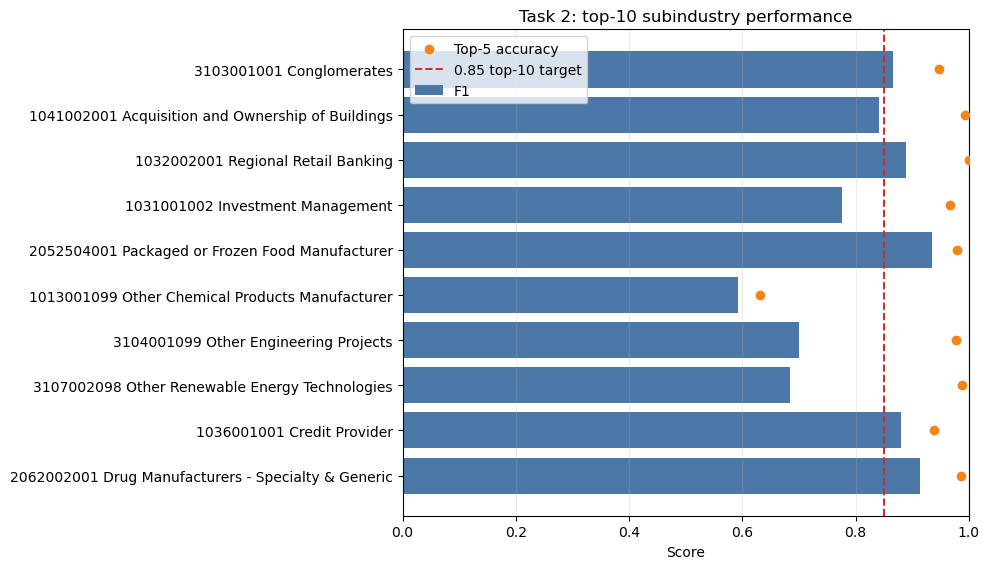

In [18]:
# Top-10 subindustry performance with ranking metrics.
scored_path = MODEL_DIR / "scored_pairs_test_task1_best_topk.csv"
score_cols = ["source_row_id", "true_leaf", "true_parent", "candidate_leaf", "candidate_parent", "label", "parent_score", "cross_encoder_logit"]
scored = pd.read_csv(scored_path, usecols=score_cols, dtype={"true_leaf": str, "true_parent": str, "candidate_leaf": str, "candidate_parent": str})
alpha = 15.0
scored["parent_score"] = pd.to_numeric(scored["parent_score"], errors="coerce").fillna(0.0)
scored["cross_encoder_logit"] = pd.to_numeric(scored["cross_encoder_logit"], errors="coerce").fillna(-999.0)
scored["final_score"] = scored["cross_encoder_logit"] + alpha * np.log(scored["parent_score"].clip(1e-12, 1.0))

rank_rows = []
for row_id, group in scored.sort_values(["source_row_id", "final_score"], ascending=[True, False]).groupby("source_row_id", sort=True):
    true_leaf = str(group["true_leaf"].iloc[0])
    true_parent = str(group["true_parent"].iloc[0])
    ranked = group["candidate_leaf"].astype(str).tolist()
    rank_rows.append({
        "source_row_id": row_id,
        "true_leaf": true_leaf,
        "true_parent": true_parent,
        "pred_leaf": ranked[0] if ranked else "",
        "pred_parent": str(ranked[0])[:8] if ranked else "",
        "candidate_covered": int(true_leaf in ranked),
        "top1_correct": int(len(ranked) > 0 and ranked[0] == true_leaf),
        "top3_correct": int(true_leaf in ranked[:3]),
        "top5_correct": int(true_leaf in ranked[:5]),
        "rank": ranked.index(true_leaf) + 1 if true_leaf in ranked else np.nan,
    })
rank_df = pd.DataFrame(rank_rows)

top10_leafs = pd.Series(y_true).value_counts().head(10).index.astype(str).tolist()
top10_rank = rank_df[rank_df["true_leaf"].isin(top10_leafs)].copy()
top10_leaf_perf = top10_df[["subindustry_code", "subindustry_name", "parent_code", "parent_name", "support", "precision", "recall", "f1"]].merge(
    top10_rank.groupby("true_leaf").agg(
        candidate_coverage=("candidate_covered", "mean"),
        top1_accuracy=("top1_correct", "mean"),
        top3_accuracy=("top3_correct", "mean"),
        top5_accuracy=("top5_correct", "mean"),
        mean_rank_when_covered=("rank", "mean"),
    ).reset_index().rename(columns={"true_leaf": "subindustry_code"}),
    on="subindustry_code",
    how="left",
)

top10_mask2 = pd.Series(y_true).isin(top10_leafs).to_numpy()
top10_leaf_summary = {
    "top10_subset_accuracy": accuracy_score(y_true[top10_mask2], y_pred[top10_mask2]),
    "top10_macro_f1": f1_score(y_true[top10_mask2], y_pred[top10_mask2], labels=top10_leafs, average="macro", zero_division=0),
    "top10_macro_precision": float(top10_leaf_perf["precision"].mean()),
    "top10_macro_recall": float(top10_leaf_perf["recall"].mean()),
    "top10_top3_accuracy": float(top10_rank["top3_correct"].mean()),
    "top10_top5_accuracy": float(top10_rank["top5_correct"].mean()),
    "top10_candidate_coverage": float(top10_rank["candidate_covered"].mean()),
}

print("Task 2 top-10 subindustry summary")
display(pd.Series(top10_leaf_summary).to_frame("score"))
print("Per top-10 subindustry metrics")
display(top10_leaf_perf.sort_values("support", ascending=False))

top10_leaf_perf.to_csv(OUT / "task2_top10_subindustry_metrics.csv", index=False)
pd.Series(top10_leaf_summary).to_csv(OUT / "task2_top10_subindustry_summary.csv")

fig, ax = plt.subplots(figsize=(10, 5.8))
plot_df = top10_leaf_perf.sort_values("support", ascending=True)
labels = plot_df["subindustry_code"] + " " + plot_df["subindustry_name"].fillna("")
ax.barh(labels, plot_df["f1"], color="#4c78a8", label="F1")
ax.scatter(plot_df["top5_accuracy"], labels, color="#f58518", label="Top-5 accuracy", zorder=3)
ax.set_xlim(0, 1)
ax.axvline(0.85, color="#d62728", linestyle="--", linewidth=1.4, label="0.85 top-10 target")
ax.set_title("Task 2: top-10 subindustry performance")
ax.set_xlabel("Score")
ax.grid(axis="x", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "task2_top10_subindustry_metrics.png", dpi=180)
plt.show()

Top-10 parent industry metrics for Task 2


,parent_code,support,parent_top1_recall,parent_top3_recall,parent_top5_recall,parent_top10_recall,candidate_coverage,subindustry_top1_accuracy,subindustry_top3_accuracy,subindustry_top5_accuracy,parent_name
6,31030010,401,0.855362,0.917706,0.962594,0.990025,0.992519,0.877805,0.927681,0.947631,Conglomerates
2,10320020,257,0.980545,1.000000,1.000000,1.000000,1.000000,0.879377,0.996109,0.996109,Banks - Regional
4,10410020,186,0.881720,0.967742,0.989247,0.989247,0.989247,0.801075,0.962366,0.983871,Real Estate Services
1,10310010,185,0.908108,0.972973,0.994595,0.994595,0.994595,0.691892,0.897297,0.956757,Asset Management
7,31040010,149,0.932886,0.973154,0.986577,1.000000,1.000000,0.577181,0.926174,0.959732,Engineering & Construction
8,31070020,145,0.889655,0.979310,0.986207,1.000000,1.000000,0.600000,0.931034,0.958621,Specialty Industrial Machinery
5,20525040,126,0.960317,0.984127,0.984127,0.984127,0.984127,0.904762,0.968254,0.976190,Packaged Foods
0,10130010,107,0.588785,0.971963,0.990654,0.990654,1.000000,0.467290,0.654206,0.663551,Chemicals
9,31110010,103,0.941748,0.990291,0.990291,0.990291,0.990291,0.679612,0.941748,0.970874,Information Technology Services
3,10410010,92,0.923913,0.989130,1.000000,1.000000,0.489130,0.456522,0.467391,0.478261,Real Estate - Development


Top-10 parent bottlenecks


,parent_code,candidate_missing,correct,reranker_miss,support,parent_name,correct_rate,candidate_missing_rate,reranker_miss_rate
7,31040010,0,86,63,149,Engineering & Construction,0.577181,0.000000,0.422819
8,31070020,0,87,58,145,Specialty Industrial Machinery,0.600000,0.000000,0.400000
0,10130010,0,50,57,107,Chemicals,0.467290,0.000000,0.532710
1,10310010,1,128,56,185,Asset Management,0.691892,0.005405,0.302703
6,31030010,3,352,46,401,Conglomerates,0.877805,0.007481,0.114713
4,10410020,2,149,35,186,Real Estate Services,0.801075,0.010753,0.188172
9,31110010,1,70,32,103,Information Technology Services,0.679612,0.009709,0.310680
2,10320020,0,226,31,257,Banks - Regional,0.879377,0.000000,0.120623
5,20525040,2,114,10,126,Packaged Foods,0.904762,0.015873,0.079365
3,10410010,47,42,3,92,Real Estate - Development,0.456522,0.510870,0.032609


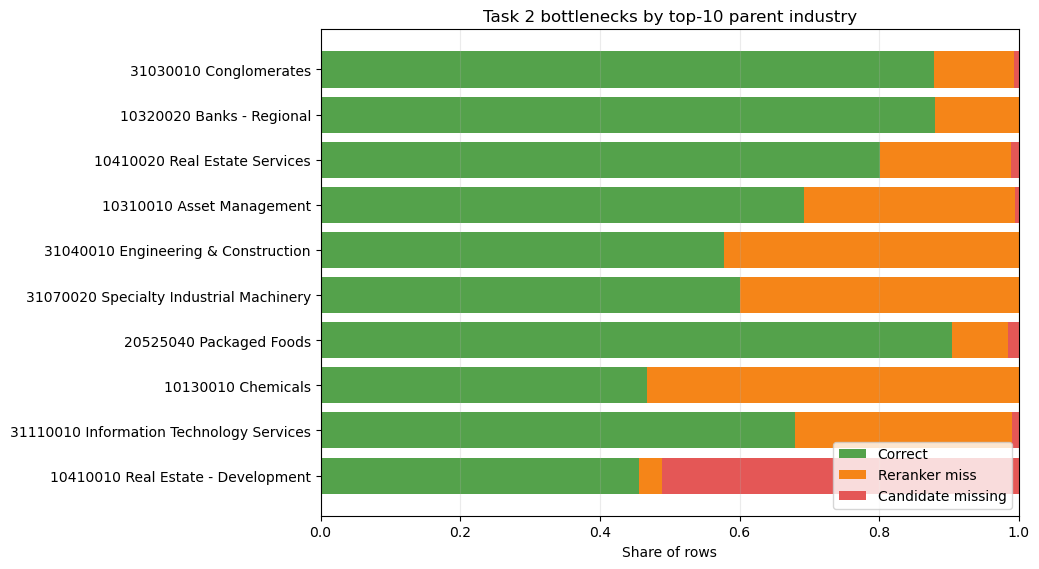

In [19]:
# Top-10 parent-industry bottleneck analysis for Task 2.
parent_candidates = pd.read_csv(MODEL_DIR / "task1_best_parent_candidates_test.csv", dtype={"true_parent": str, "true_leaf": str})
parent_candidates["top_parent_codes"] = parent_candidates["top_parent_codes"].map(json.loads)

def in_topk(codes, truth, k):
    return int(str(truth) in list(map(str, codes[:k])))

parent_rows = []
for row in parent_candidates.itertuples(index=False):
    parent_rows.append({
        "source_row_id": int(row.source_row_id),
        "true_parent": str(row.true_parent),
        "parent_top1": in_topk(row.top_parent_codes, row.true_parent, 1),
        "parent_top3": in_topk(row.top_parent_codes, row.true_parent, 3),
        "parent_top5": in_topk(row.top_parent_codes, row.true_parent, 5),
        "parent_top10": in_topk(row.top_parent_codes, row.true_parent, 10),
    })
parent_rank_df = pd.DataFrame(parent_rows)
row_level = rank_df.merge(parent_rank_df, on=["source_row_id", "true_parent"], how="left")
row_level["error_type"] = np.select(
    [row_level["top1_correct"].eq(1), row_level["candidate_covered"].eq(0)],
    ["correct", "candidate_missing"],
    default="reranker_miss",
)

parent_counts = row_level["true_parent"].value_counts().head(10)
top10_parent_perf = (
    row_level[row_level["true_parent"].isin(parent_counts.index)]
    .groupby("true_parent")
    .agg(
        support=("source_row_id", "count"),
        parent_top1_recall=("parent_top1", "mean"),
        parent_top3_recall=("parent_top3", "mean"),
        parent_top5_recall=("parent_top5", "mean"),
        parent_top10_recall=("parent_top10", "mean"),
        candidate_coverage=("candidate_covered", "mean"),
        subindustry_top1_accuracy=("top1_correct", "mean"),
        subindustry_top3_accuracy=("top3_correct", "mean"),
        subindustry_top5_accuracy=("top5_correct", "mean"),
    )
    .reset_index()
    .rename(columns={"true_parent": "parent_code"})
)
top10_parent_perf["parent_name"] = top10_parent_perf["parent_code"].map(parent_name).fillna("")
top10_parent_perf = top10_parent_perf.sort_values("support", ascending=False)

top10_parent_bottleneck = (
    row_level[row_level["true_parent"].isin(parent_counts.index)]
    .pivot_table(index="true_parent", columns="error_type", values="source_row_id", aggfunc="count", fill_value=0)
    .reset_index()
    .rename(columns={"true_parent": "parent_code"})
)
for col in ["correct", "candidate_missing", "reranker_miss"]:
    if col not in top10_parent_bottleneck:
        top10_parent_bottleneck[col] = 0
top10_parent_bottleneck = top10_parent_bottleneck.merge(top10_parent_perf[["parent_code", "support", "parent_name"]], on="parent_code", how="left")
for col in ["correct", "candidate_missing", "reranker_miss"]:
    top10_parent_bottleneck[col + "_rate"] = top10_parent_bottleneck[col] / top10_parent_bottleneck["support"]
top10_parent_bottleneck = top10_parent_bottleneck.sort_values("reranker_miss", ascending=False)

print("Top-10 parent industry metrics for Task 2")
display(top10_parent_perf)
print("Top-10 parent bottlenecks")
display(top10_parent_bottleneck)

top10_parent_perf.to_csv(OUT / "task2_top10_parent_industry_metrics.csv", index=False)
top10_parent_bottleneck.to_csv(OUT / "task2_top10_parent_bottlenecks.csv", index=False)
row_level.to_csv(OUT / "task2_row_level_bottlenecks.csv", index=False)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
plot_df = top10_parent_bottleneck.sort_values("support", ascending=True)
labels = plot_df["parent_code"] + " " + plot_df["parent_name"].fillna("")
left = np.zeros(len(plot_df))
for col, color, label in [
    ("correct_rate", "#54a24b", "Correct"),
    ("reranker_miss_rate", "#f58518", "Reranker miss"),
    ("candidate_missing_rate", "#e45756", "Candidate missing"),
]:
    ax.barh(labels, plot_df[col], left=left, color=color, label=label)
    left += plot_df[col].to_numpy()
ax.set_xlim(0, 1)
ax.set_title("Task 2 bottlenecks by top-10 parent industry")
ax.set_xlabel("Share of rows")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUT / "task2_top10_parent_bottlenecks.png", dpi=180)
plt.show()

In [20]:
print("Summary")
print("Best Task 2 model: Task1-best parent candidates + cross-encoder reranker, alpha=15")
print(f"Accuracy/top-1: {metrics['test']['accuracy']:.4f}")
print(f"Macro F1:       {metrics['test']['macro_f1']:.4f}")
print(f"Weighted F1:    {metrics['test']['weighted_f1']:.4f}")
print(f"Top-10 macro:   {metrics['test']['top10_macro_f1']:.4f}")
print(f"Top-3 accuracy: {metrics['test']['top3_accuracy']:.4f}")
print(f"Top-5 accuracy: {metrics['test']['top5_accuracy']:.4f}")
print(f"Outputs written to: {OUT.resolve()}")

Summary
Best Task 2 model: Task1-best parent candidates + cross-encoder reranker, alpha=15
Accuracy/top-1: 0.7489
Macro F1:       0.5761
Weighted F1:    0.7310
Top-10 macro:   0.8905
Top-3 accuracy: 0.9014
Top-5 accuracy: 0.9241
Outputs written to: C:\Users\shami\OneDrive\Desktop\capstone\final_best_models_package\task2\analysis_outputs
